Alexander Simmons 02/16/2026

Projectile Motion Predictor Introduction:

This project serves as an application of Support Vector Regression (SVR) to predict projectile range in classical physics, given initial velocity, angle from horizontal, and height from base. Through feature engineering the model is able to achieve an R² of 0.9996 on test data, explaining nearly all variance in the range. Hyperparameter tuning via grid search enables the SVR model to make accurate, generalizable predictions. These results highlight the potential of SVR in deterministic physics simulations and the hopes for SVR's usecase in real-world scenarios with air resistance. 

In [29]:
import pandas as pd

data_set = 'projectile_parameters.csv'
solution_set = 'solutions.csv'
data = pd.read_csv(data_set)
solutions = pd.read_csv(solution_set)

print(data.head())

   v0 (m/s)    h (m)  theta (degrees)
0   10.5297  14.1027          63.9073
1   10.0533  32.6073          69.1357
2   19.1562  14.2528          80.4338
3    5.2438  61.0565          52.1114
4    7.8428  61.0924          60.2304


This section loads test data which will later be split and used for training.

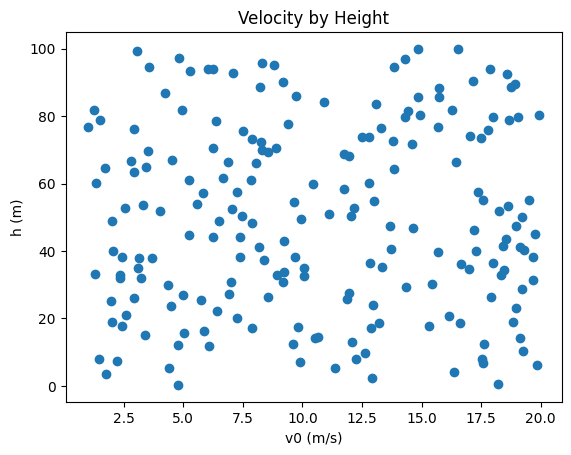

In [30]:
import matplotlib.pyplot as plt

plt.scatter(data["v0 (m/s)"], data["h (m)"])
plt.xlabel("v0 (m/s)")
plt.ylabel("h (m)")
plt.title("Velocity by Height")
plt.show()

Note there is no direct correlation between velocity and height, nor velocity and launch angle. The point of using SVR is to model the correlation between these three factors and range.

In [31]:
from sklearn.model_selection import train_test_split

X = data[['v0 (m/s)', 'h (m)', 'theta (degrees)']]
y = solutions['Range (m)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training data size:", X_train.shape)
print("Test data size:", X_test.shape)

Training data size: (160, 3)
Test data size: (40, 3)


Here we split the data into training for the model and test data which will be used to verify the accuracy of the model.

In [32]:
# Create and train a linear regression model (predicts continuous range)
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)  # Learns the relationship

predictions = model.predict(X_test)
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
print(f"MSE: {mse:.2f}, R²: {r2:.2f}")

MSE: 91.16, R²: 0.67


Linear Regression as expected only explains 67% of the variance in range (R²=0.67) with a high Mean Squared Error (MSE) of 91.16 m² indicating this model's range predictions deviate heavily from the true values. From here SVR is chosen as a better fitting model because it is able to explain non-linear correlations. When height = 0, Range = [v₀² sin(2θ)] / g., indicating an inherently non-linear relationship.

In [33]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
import numpy as np

# hyperparameters
data['theta_rad'] = np.radians(data['theta (degrees)'])  # Convert to radians
data['sin_theta'] = np.sin(data['theta_rad'])
data['cos_theta'] = np.cos(data['theta_rad'])
data['v0_squared'] = data['v0 (m/s)']**2
data['v0_sin_theta'] = data['v0 (m/s)'] * data['sin_theta']
data['v0_cos_theta'] = data['v0 (m/s)'] * data['cos_theta']
data['gravity (m/s^2)'] = 9.8

# Update X with new features
X = data[['v0 (m/s)', 'h (m)', 'theta_rad', 'sin_theta', 'cos_theta', 'v0_squared', 'v0_sin_theta', 'v0_cos_theta']]

param_grid = {'C': [100, 1000, 10000], 'gamma': ['scale', 0.01, 0.1]}
grid = GridSearchCV(SVR(kernel='rbf'), param_grid, cv=3, scoring='r2')
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
predictions = best_model.predict(X_test)
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
print(f"MSE: {mse:.3f}, R²: {r2:.4f}")

MSE: 0.107, R²: 0.9996


After feature engineering and hyperparameter tuning via grid search, an acceptable SVR model is born.

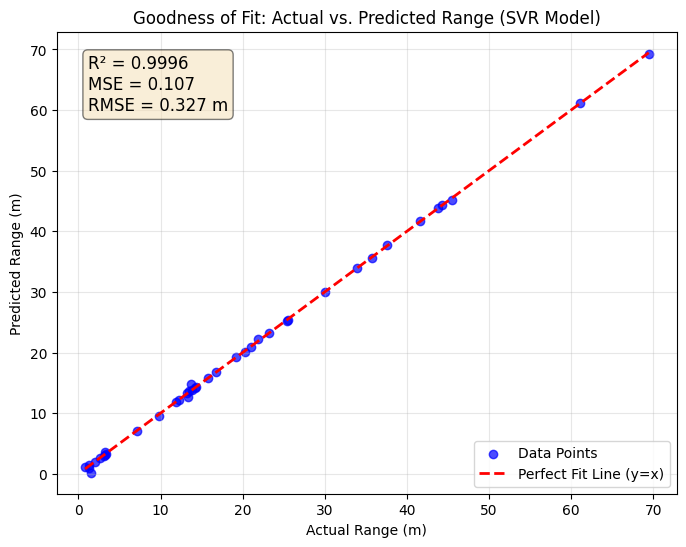

In [34]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

rmse = mse ** 0.5  # Root MSE for units (meters)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.7, color='blue', label='Data Points')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', linewidth=2, label='Perfect Fit Line (y=x)')

# Graph Annotation
plt.text(0.05, 0.95, f'R² = {r2:.4f}\nMSE = {mse:.3f}\nRMSE = {rmse:.3f} m', 
         transform=plt.gca().transAxes, fontsize=12, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.xlabel('Actual Range (m)')
plt.ylabel('Predicted Range (m)')
plt.title('Goodness of Fit: Actual vs. Predicted Range (SVR Model)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

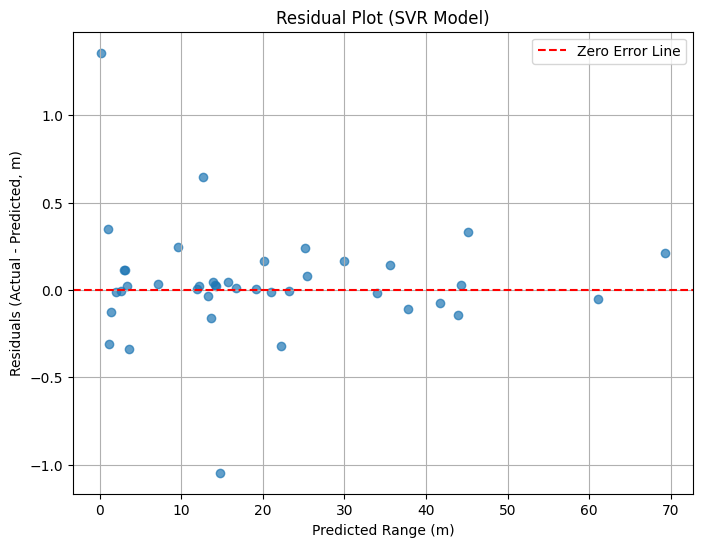

In [35]:
residuals = y_test - predictions

plt.figure(figsize=(8, 6))
plt.scatter(predictions, residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--', label='Zero Error Line')
plt.xlabel('Predicted Range (m)')
plt.ylabel('Residuals (Actual - Predicted, m)')
plt.title('Residual Plot (SVR Model)')
plt.legend()
plt.grid(True)
plt.show()

Note that near all residuals are within half a meter of the accepted values for range. This is a sign of a good model.